# Volatility-Adjusted Momentum — 6M — Equal Weight

One signal, one formation horizon and one maintenance method. The experiment contains nine cells: rebalance every 1, 3 or 6 months × target N=12, 24 or 50.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))
from momentum_india.notebook_views import ResearchNotebook

research = ResearchNotebook('vol_adjusted', '6M', 'equal_weight')

## 1. Signal and portfolio rule

Score = formation-period price return / annualized sample standard deviation of daily log returns. Annualization uses √252. The signal rewards stronger returns per unit of realized variability; it does not set inverse-volatility portfolio weights.

Each selected stock targets 1/N of pre-trade equity at a scheduled rebalance. If K<N qualify, target cash is (N−K)/N before charges; eligible stocks are not enlarged to 1/K. Sales precede purchases, which are reduced proportionally if charges or unfilled sales restrict available cash. Actual weights can therefore differ slightly from targets. Membership is rebuilt from current ranks without a retention buffer.

## 2. Universe → ranking → actual portfolio

The example uses the latest monthly N=24 signal and exposes the ranking inputs and actual target weights.

Symbol,Return / volatility,MDTV (INR)
NSE:CUPID-EQ,3.563,"2,261,224,535.95"
NSE:YASHO-EQ,3.430,"37,220,195.50"
NSE:UFBL-EQ,3.330,"42,078,240.59"
NSE:HFCL-EQ,3.264,"3,688,024,397.99"
NSE:CPPLUS-EQ,3.199,"588,775,647.85"
NSE:WELCORP-EQ,3.186,"698,746,108.38"
NSE:DIACABS-EQ,2.993,"490,913,783.79"
NSE:RPTECH-EQ,2.761,"78,147,051.55"
NSE:LAURUSLABS-EQ,2.736,"2,123,882,567.10"
NSE:SHADOWFAX-EQ,2.634,"320,801,875.19"


Symbol,Leg,Actual weight,Current selection,Execution status,Return / volatility,MDTV (INR)
NSE:CUPID-EQ,long,2.1%,True,selected,3.563,"2,261,224,535.95"
NSE:YASHO-EQ,long,2.1%,True,selected,3.430,"37,220,195.50"
NSE:UFBL-EQ,long,4.1%,True,selected,3.330,"42,078,240.59"
NSE:HFCL-EQ,long,3.7%,True,selected,3.264,"3,688,024,397.99"
NSE:CPPLUS-EQ,long,4.1%,True,selected,3.199,"588,775,647.85"
NSE:WELCORP-EQ,long,3.2%,True,selected,3.186,"698,746,108.38"
NSE:DIACABS-EQ,long,2.1%,True,selected,2.993,"490,913,783.79"
NSE:RPTECH-EQ,long,4.1%,True,selected,2.761,"78,147,051.55"
NSE:LAURUSLABS-EQ,long,2.1%,True,selected,2.736,"2,123,882,567.10"
NSE:SHADOWFAX-EQ,long,2.1%,True,selected,2.634,"320,801,875.19"


Symbol,Formation start,Start adjusted close,Signal close date,End adjusted close,Formation price return
NSE:CUPID-EQ,2026-01-30,80.20,2026-07-31,230.62,187.6%


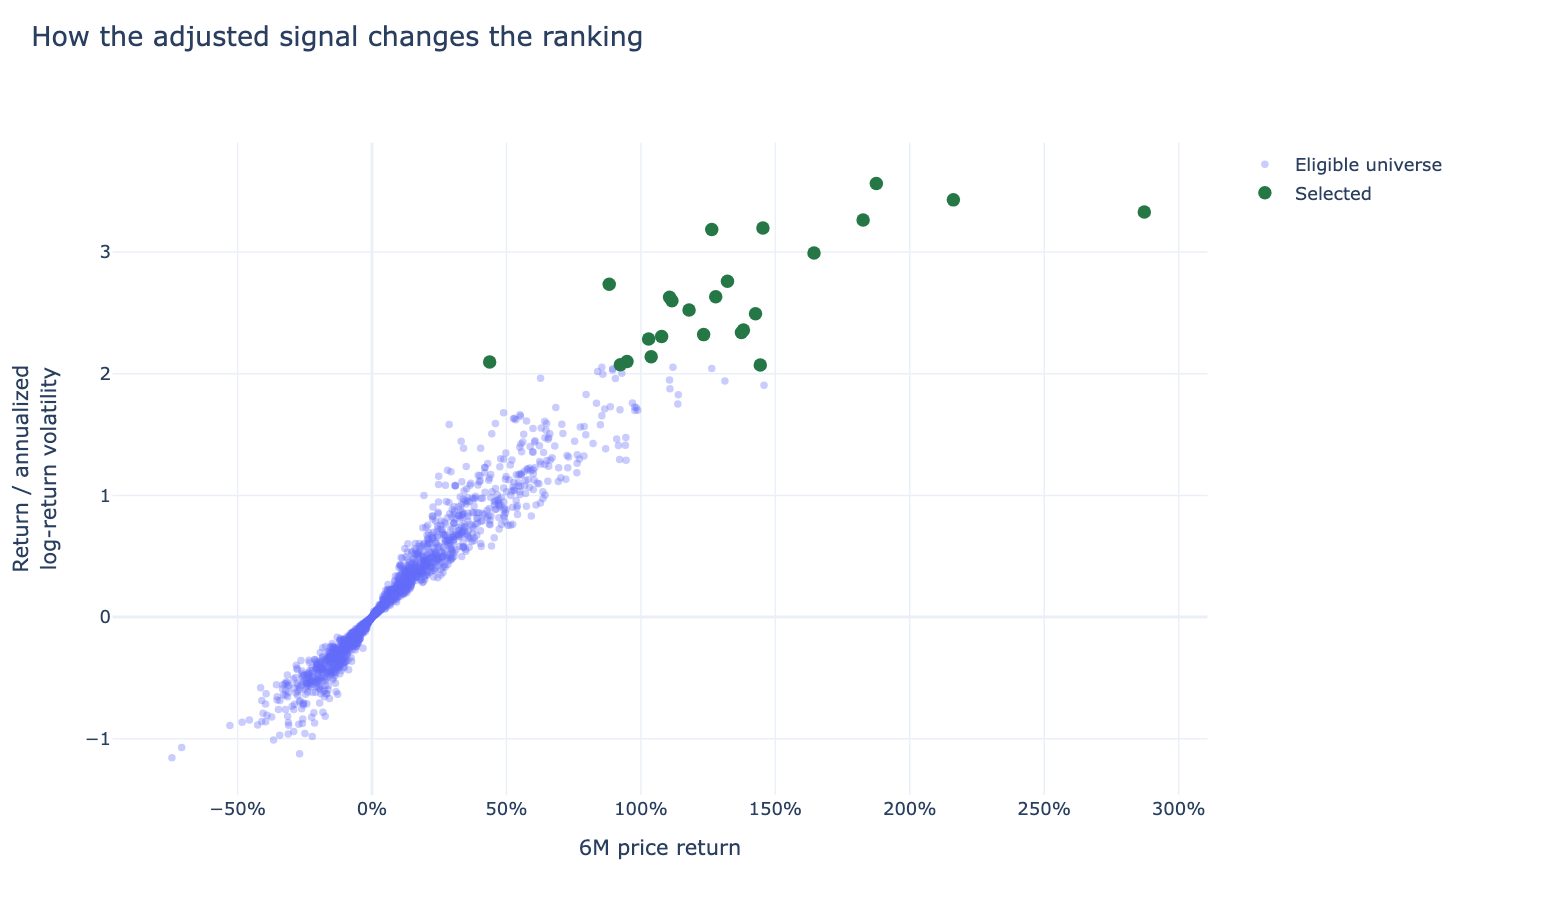

In [2]:
research.snapshot()

## 3. Return layers across all nine cells

Raw is before trading charges. After-cost gross/pre-tax deducts modeled trading charges. The long-only post-tax overlay additionally applies the annual equity-gains ledger. The academic reference instead compares raw and borrowing-adjusted layers.

In [3]:
research.layers_bridge()

Rebalance,First date,Last date,Sessions
1M,2007-05-03,2026-08-28,4771
3M,2007-07-02,2026-08-28,4729
6M,2007-07-02,2026-08-28,4729


Rebalance,N,Raw,After costs,Post-tax overlay
1M,12,17.6%,16.1%,14.0%
1M,24,17.0%,15.6%,13.5%
1M,50,19.1%,17.7%,15.4%
3M,12,18.9%,18.1%,15.6%
3M,24,16.3%,15.5%,13.3%
3M,50,15.7%,14.9%,12.9%
6M,12,11.5%,11.1%,9.3%
6M,24,14.3%,13.8%,11.6%
6M,50,15.9%,15.4%,13.2%


## 4. Risk-adjusted results

Sharpe uses daily excess returns relative to the liquid fund. VaR and expected shortfall are historical monthly 95% loss measures. Partial first/last months are included. Time below prior peak counts days awaiting a new all-time high—not losing days. The initial invested capital is included as the first peak.

In [4]:
research.risk_grid()

Rebalance,N,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,12,14.0%,0.412,-75.0%,8.6%
1M,24,13.5%,0.395,-72.1%,9.8%
1M,50,15.4%,0.508,-71.0%,8.5%
3M,12,15.6%,0.447,-74.2%,11.9%
3M,24,13.3%,0.375,-73.7%,9.7%
3M,50,12.9%,0.385,-71.3%,8.8%
6M,12,9.3%,0.201,-71.6%,11.3%
6M,24,11.6%,0.304,-74.8%,10.3%
6M,50,13.2%,0.388,-72.5%,9.3%


Rebalance,N,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,12,15.9%,94.3%,1654
1M,24,16.8%,93.5%,1640
1M,50,15.0%,91.5%,1582
3M,12,17.7%,94.5%,1647
3M,24,16.3%,93.7%,1679
3M,50,14.7%,93.0%,1647
6M,12,16.5%,96.0%,1784
6M,24,17.1%,94.2%,1731
6M,50,16.1%,92.3%,1645


### CAGR

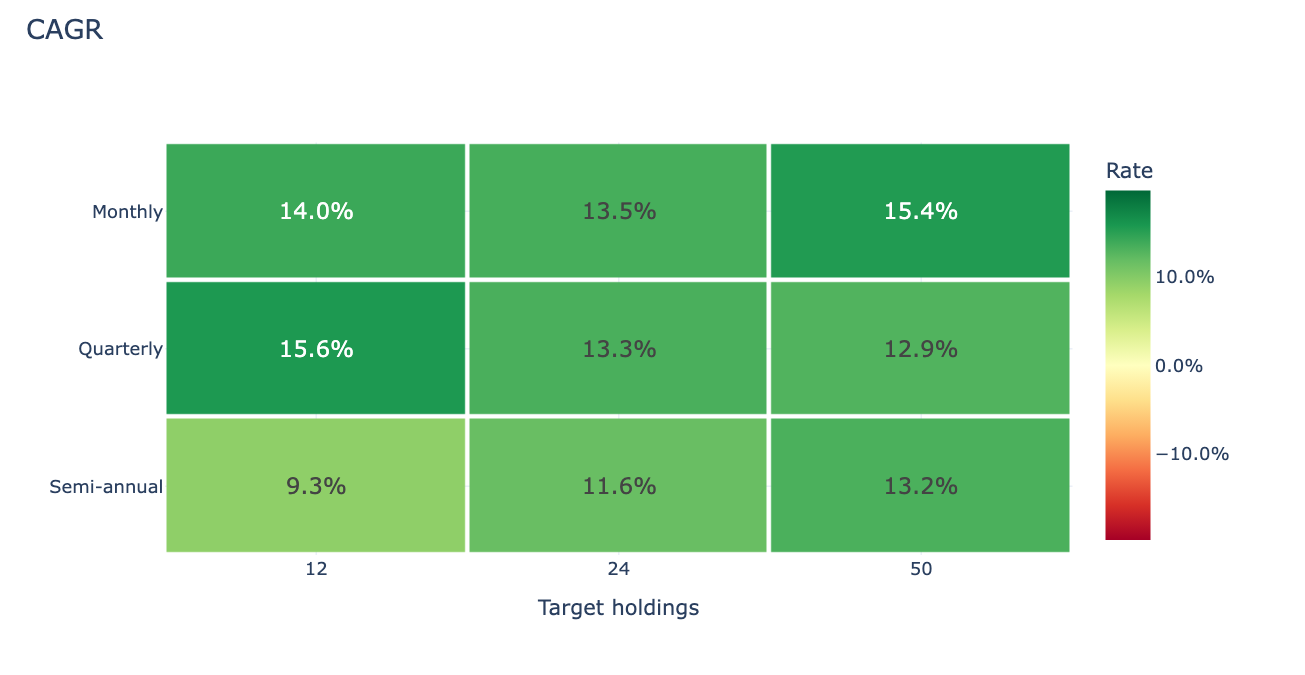

In [5]:
research.heatmap('cagr')

### Sharpe ratio

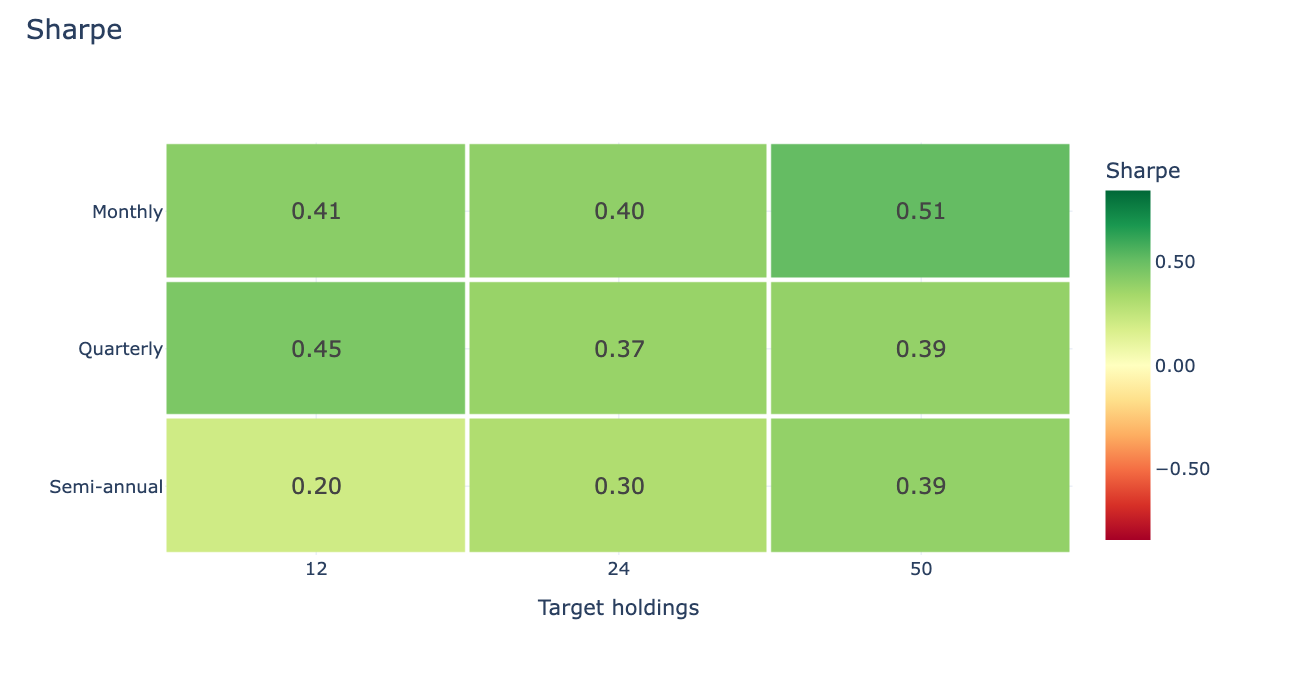

In [6]:
research.heatmap('sharpe')

### Maximum drawdown

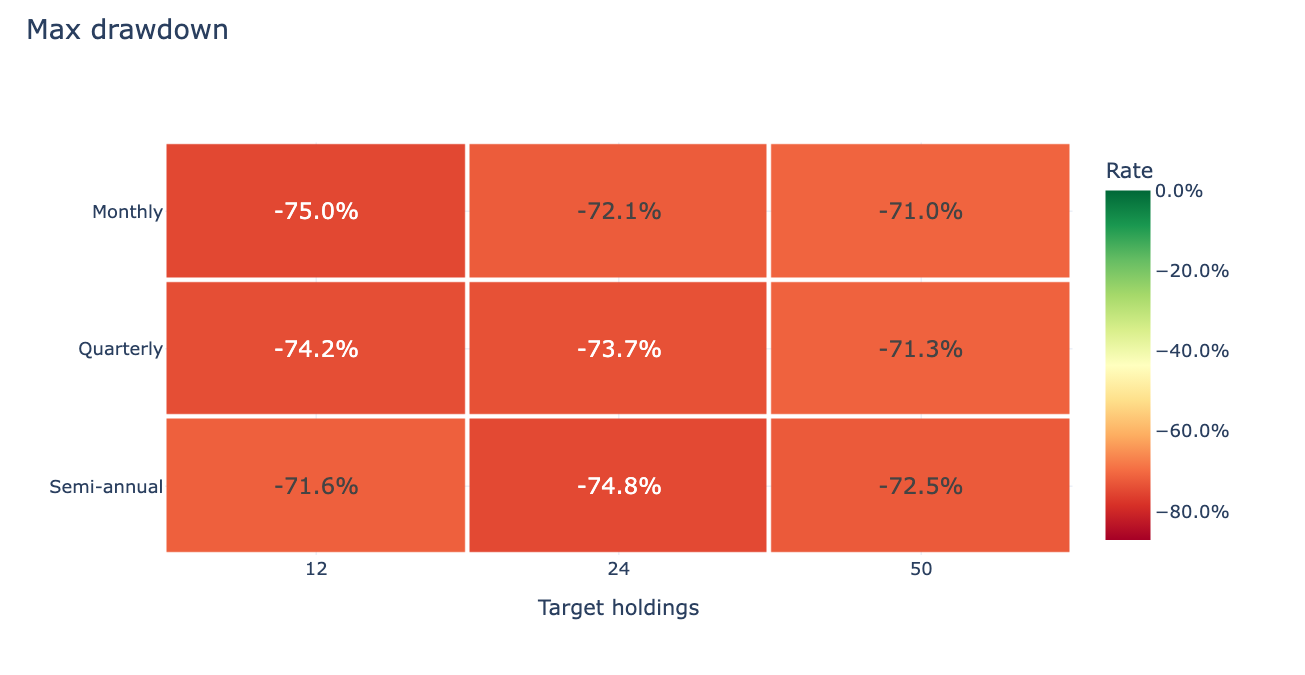

In [7]:
research.heatmap('maximum_drawdown')

### Monthly 95% VaR

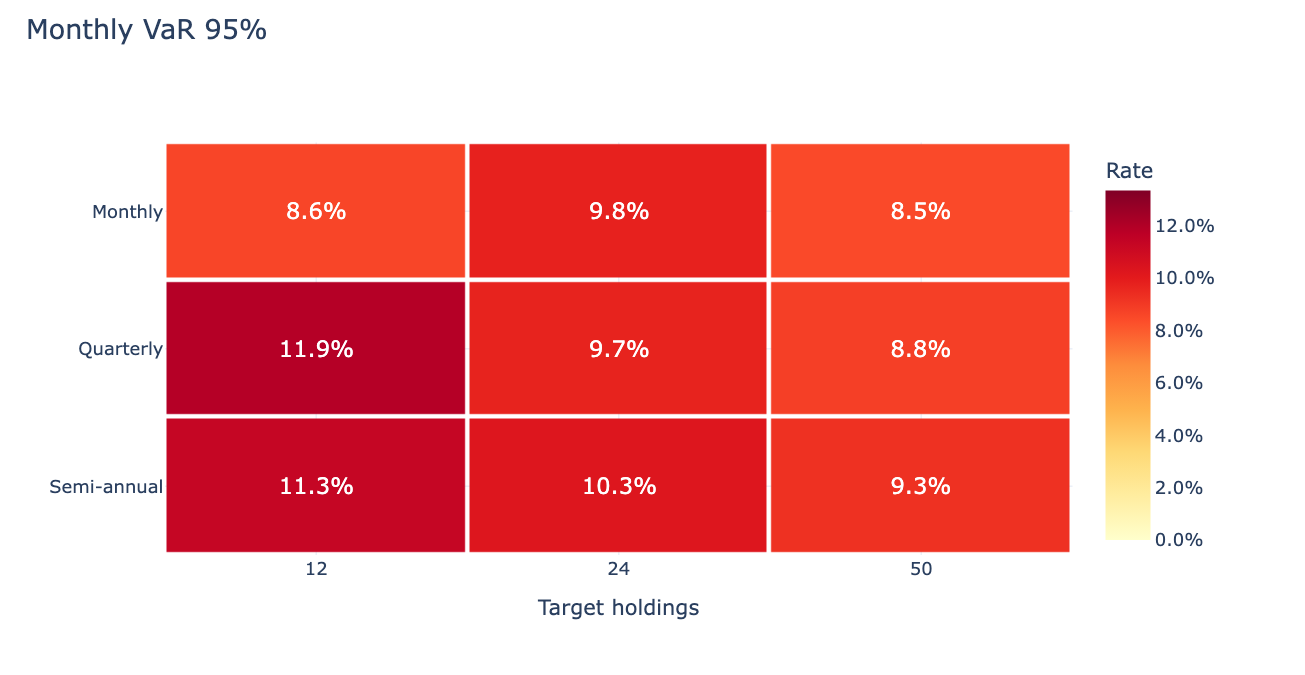

In [8]:
research.heatmap('monthly_var_95')

## 5. Equity paths and matched risks

Each chart fixes breadth and compares rebalance frequencies. Final-layer curves and the price benchmark start visible; other return layers remain in the selectable legend. Logarithmic axes make early and late periods comparable; the bottom range slider preserves the full history. Curves display weekly observations for readability, while every statistic uses the complete daily series.

### N=12

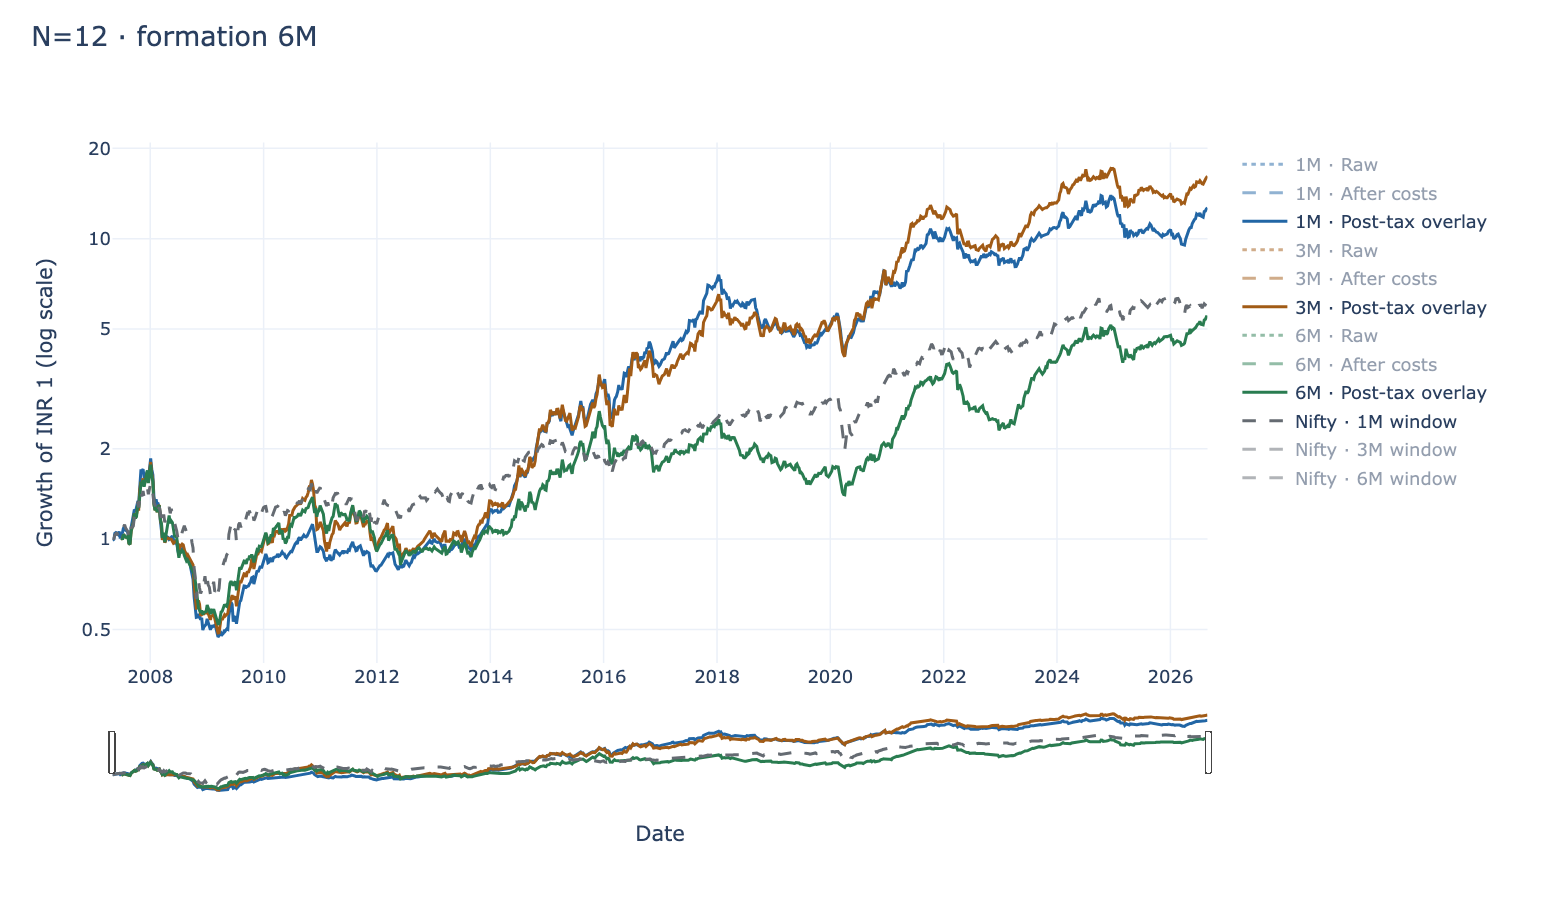

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Raw,17.6%,0.564,-73.3%,8.3%
1M,After costs,16.1%,0.504,-73.9%,8.3%
1M,Post-tax overlay,14.0%,0.412,-75.0%,8.6%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Raw,18.9%,0.570,-72.3%,11.5%
3M,After costs,18.1%,0.541,-72.5%,11.5%
3M,Post-tax overlay,15.6%,0.447,-74.2%,11.9%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%
6M,Raw,11.5%,0.300,-69.2%,10.7%
6M,After costs,11.1%,0.280,-69.3%,10.7%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Raw,15.4%,93.0%,1597
1M,After costs,15.4%,93.5%,1647
3M,Raw,17.0%,93.6%,1597
3M,After costs,17.0%,93.7%,1598
6M,Raw,15.6%,94.9%,1731
6M,After costs,15.6%,95.0%,1732
1M,Post-tax overlay,15.9%,94.3%,1654
3M,Post-tax overlay,17.7%,94.5%,1647
6M,Post-tax overlay,16.5%,96.0%,1784
1M,Nifty 50 price,13.1%,92.4%,1520


In [9]:
research.equity(12)

### N=24

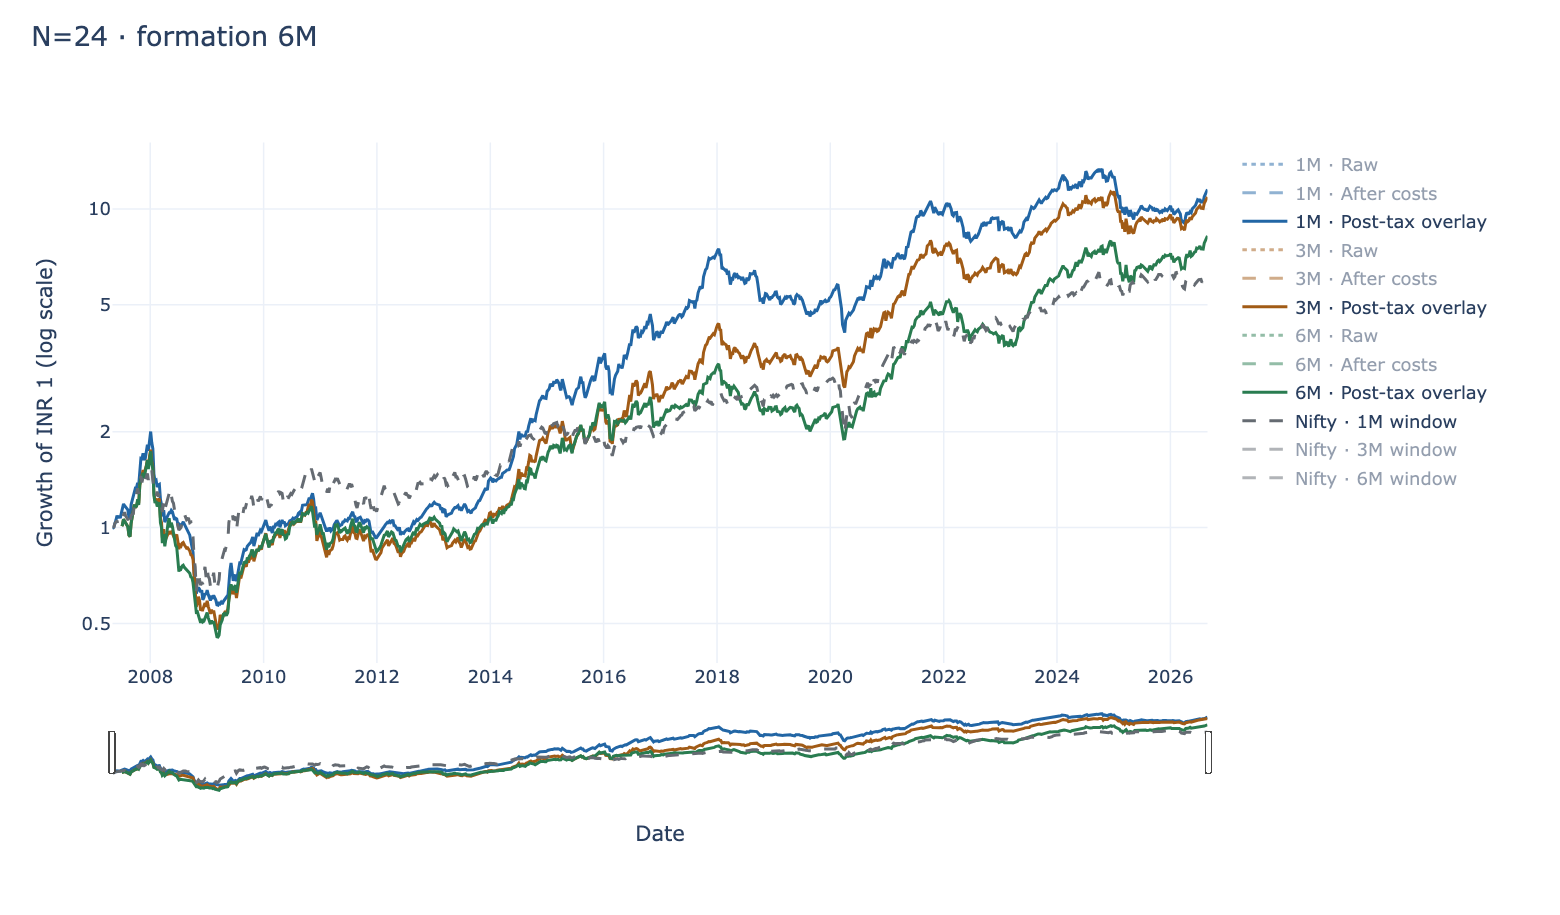

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Raw,17.0%,0.556,-70.5%,9.2%
1M,After costs,15.6%,0.493,-71.0%,9.2%
1M,Post-tax overlay,13.5%,0.395,-72.1%,9.8%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Raw,16.3%,0.502,-71.9%,9.7%
3M,After costs,15.5%,0.469,-72.1%,9.7%
3M,Post-tax overlay,13.3%,0.375,-73.7%,9.7%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%
6M,Raw,14.3%,0.421,-72.6%,10.3%
6M,After costs,13.8%,0.400,-72.7%,10.3%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Raw,16.4%,91.8%,1581
1M,After costs,16.4%,92.5%,1597
3M,Raw,15.9%,92.7%,1643
3M,After costs,16.0%,92.9%,1648
6M,Raw,16.6%,92.8%,1679
6M,After costs,16.6%,93.0%,1687
1M,Post-tax overlay,16.8%,93.5%,1640
3M,Post-tax overlay,16.3%,93.7%,1679
6M,Post-tax overlay,17.1%,94.2%,1731
1M,Nifty 50 price,13.1%,92.4%,1520


In [10]:
research.equity(24)

### N=50

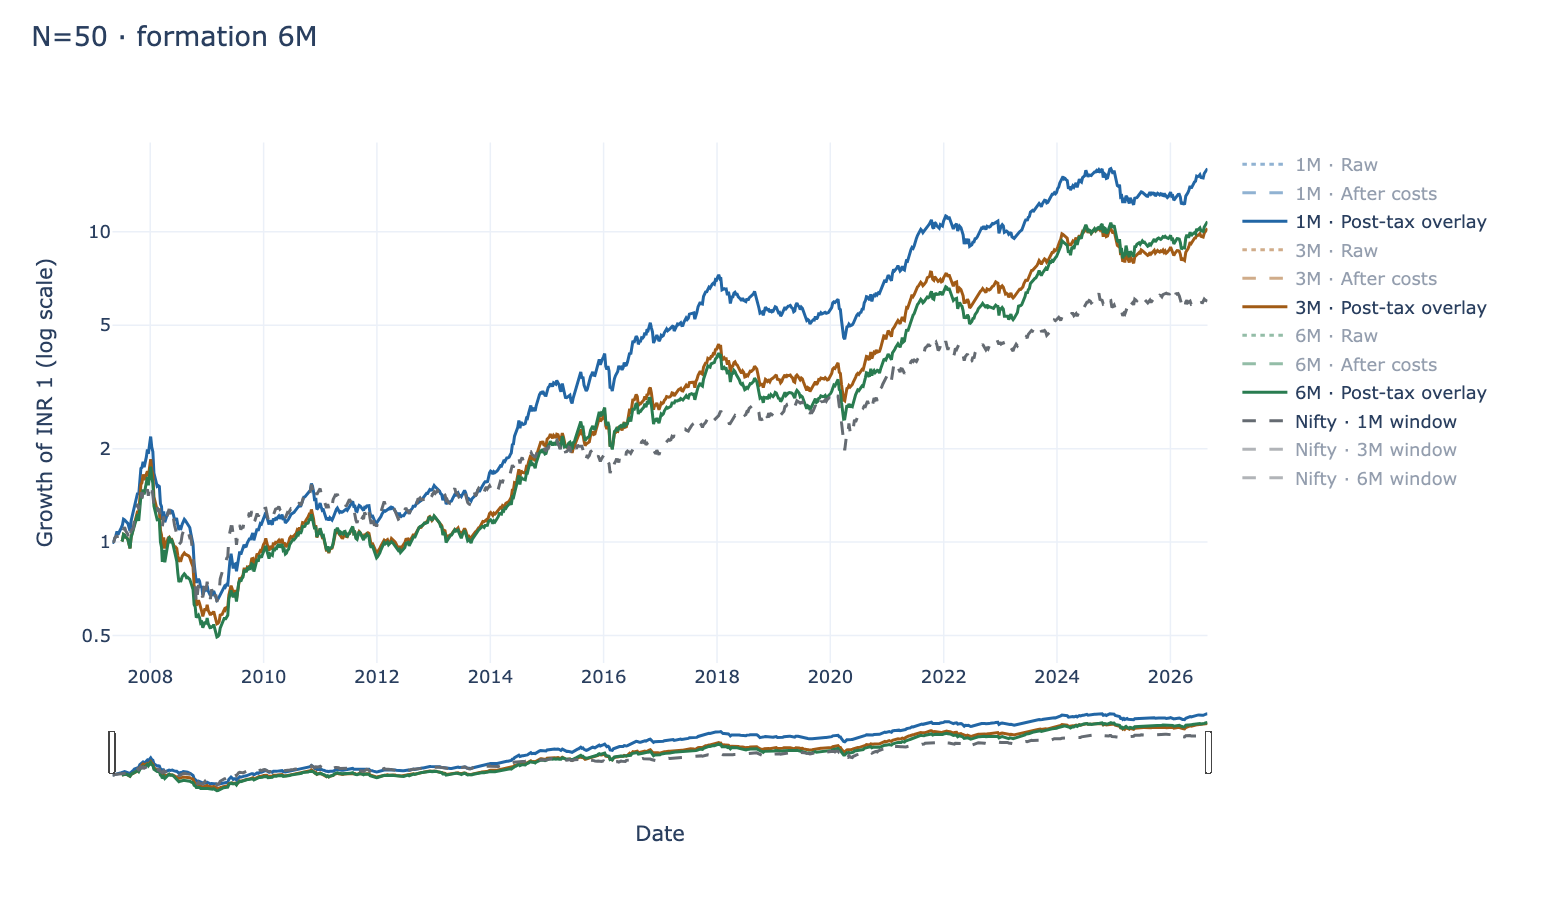

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Raw,19.1%,0.687,-69.3%,8.3%
1M,After costs,17.7%,0.624,-69.8%,8.3%
1M,Post-tax overlay,15.4%,0.508,-71.0%,8.5%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Raw,15.7%,0.523,-69.4%,8.0%
3M,After costs,14.9%,0.487,-69.7%,8.0%
3M,Post-tax overlay,12.9%,0.385,-71.3%,8.8%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%
6M,Raw,15.9%,0.514,-70.2%,8.6%
6M,After costs,15.4%,0.491,-70.3%,8.7%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Raw,14.6%,89.7%,1561
1M,After costs,14.6%,90.3%,1576
3M,Raw,14.2%,91.5%,1599
3M,After costs,14.2%,91.9%,1640
6M,Raw,15.6%,91.1%,1598
6M,After costs,15.6%,91.3%,1602
1M,Post-tax overlay,15.0%,91.5%,1582
3M,Post-tax overlay,14.7%,93.0%,1647
6M,Post-tax overlay,16.1%,92.3%,1645
1M,Nifty 50 price,13.1%,92.4%,1520


In [11]:
research.equity(50)

## 6. Recovery burden

The longest underwater episode is shown by its peak, trough and recovery dates. Unrecovered episodes remain explicitly open.

In [12]:
research.recovery()

Series,Peak,Trough,Recovery,Sessions,Calendar days,Episode loss
1M,2008-01-07,2009-03-09,2014-09-02,1640,2429,-72.1%
3M,2008-01-07,2009-03-09,2014-11-03,1679,2491,-73.7%
6M,2008-01-07,2009-03-09,2015-01-19,1731,2568,-74.8%
Nifty · 1M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%
Nifty · 3M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%
Nifty · 6M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%


## 7. Portfolio behavior

Scheduled turnover is (buy value + sell value)/(2 × pre-trade equity). Retention compares successive scheduled target name sets. Cash and total charges include the intervening daily path.

In [13]:
research.behavior()

Rebalance,N,Mean names at rebalance,Mean cash weight,Scheduled name retention
1M,12,20.80,1.1%,67.6%
1M,24,37.83,0.9%,67.5%
1M,50,78.53,0.7%,71.1%
3M,12,15.61,1.8%,34.2%
3M,24,33.01,1.5%,40.7%
3M,50,76.14,1.1%,50.4%
6M,12,16.38,2.6%,27.4%
6M,24,31.97,2.1%,26.1%
6M,50,66.90,1.6%,29.3%


Rebalance,N,Mean scheduled turnover,All trading charges (INR),Days with stop sales
1M,12,35.8%,"11,656,969.74",0
1M,24,35.3%,"12,240,552.49",0
1M,50,31.6%,"12,902,463.53",0
3M,12,66.7%,"7,689,782.48",0
3M,24,62.5%,"5,254,177.08",0
3M,50,54.0%,"4,682,384.93",0
6M,12,72.4%,"1,650,234.97",0
6M,24,77.7%,"2,485,104.97",0
6M,50,75.2%,"3,180,412.31",0


## 8. Market-state attribution

This is an observation, not an extra strategy filter. Prior-close Nifty 50 versus SMA(200) defines up/down; 63-session volatility versus its expanding historical median defines high/low volatility. The representative monthly N=24 path is shown with shaded states.

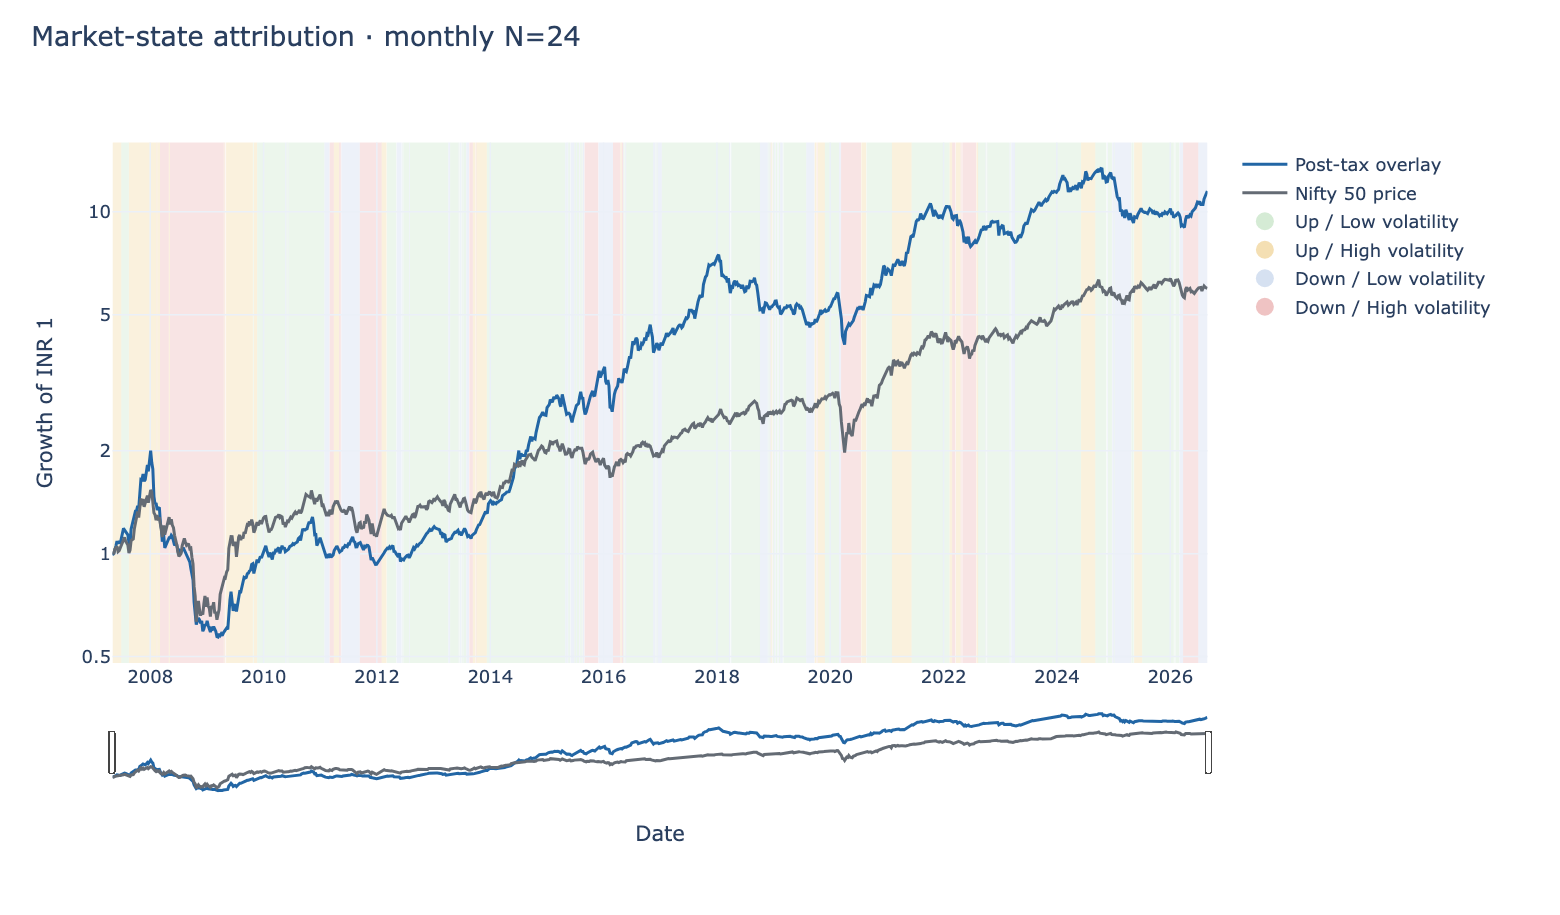

Market state,Sessions,Mean daily return,Daily volatility,Positive days
Down / High volatility,748,-0.03%,1.34%,53.74%
Down / Low volatility,609,-0.05%,1.43%,52.38%
Up / High volatility,720,0.22%,1.49%,62.92%
Up / Low volatility,2694,0.07%,1.09%,58.50%


In [14]:
research.regimes()

## 9. Complete portfolio and trade evidence

Risk metrics are included in the repository. Complete portfolio and trade CSVs belong to the local full-data research run.

In [15]:
research.portfolio_exports()

Rebalance,N,First rebalance,Last rebalance,Rebalance dates,Holding rows
1M,12,2007-05-03,2026-08-03,232,4826
1M,24,2007-05-03,2026-08-03,232,8776
1M,50,2007-05-03,2026-08-03,232,18220
3M,12,2007-07-02,2026-07-01,77,1202
3M,24,2007-07-02,2026-07-01,77,2542
3M,50,2007-07-02,2026-07-01,77,5863
6M,12,2007-07-02,2026-07-01,39,639
6M,24,2007-07-02,2026-07-01,39,1247
6M,50,2007-07-02,2026-07-01,39,2609


## Findings

In [16]:
research.conclusion()

Matched reference: [Raw Momentum — 6M — Equal Weight](02_raw_momentum_6m_equal_weight.ipynb). The comparison holds formation, maintenance, frequency and N fixed.